In [17]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Optional
from langgraph.checkpoint.memory import InMemorySaver

In [8]:
class InterruptSchema(TypedDict):
    age: int

In [ ]:
from langgraph.types import interrupt , Command
def age_node(state: InterruptSchema) -> dict:
    # age = state['age']
    response = interrupt('what is your age')
    return {
        "age":response
    }

In [21]:
graph = StateGraph(InterruptSchema)
graph.add_node('age_node',age_node)
graph.add_edge(START,'age_node')
graph.add_edge('age_node',END)

In [22]:
checkpointer = InMemorySaver()

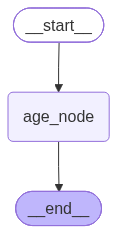

In [23]:
app = graph.compile(checkpointer=checkpointer)
app

In [25]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

In [26]:
result = app.invoke({'age':None},config=config)
print(result)

{'age': None, '__interrupt__': [Interrupt(value='what is your age', id='6720bb7cb2e49b2f852be79cf4c11e22')]}


In [28]:
result = app.invoke(Command(resume=23),config=config)
result

{'age': 23}